In [1]:
from itertools import chain
import anndata as ad
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
import scanorama

sc.logging.print_header()

Package,Version
anndata,0.12.7
matplotlib,3.10.8
numpy,2.3.5
pandas,2.3.3
scanpy,1.11.5
seaborn,0.13.2
scanorama,1.7.4
Component,Info
Python,"3.11.5 (main, Sep 11 2023, 13:54:46) [GCC 11.2.0]"
OS,Linux-4.18.0-553.141.2.el8_10.x86_64-x86_64-with-glibc2.28


In [2]:
# Load the preprocessed thymus dataset
adata_clustered = sc.read('/cluster/pixstor/warrenwc-lab/users/evan/SingleCell/Total_lung/total_lung_cell_type')

# Load the raw counts dataset
adata_raw = sc.read('/cluster/pixstor/warrenwc-lab/users/rachel/single-cell/251217-chickenRBCs/3-cluster/raw_counts.h5ad')

In [3]:
%matplotlib inline
matplotlib.rcParams["figure.figsize"] = (7.0, 7.0)

In [4]:
# Load the aggregation data (from CSV)
aggregation = pd.read_csv("/cluster/pixstor/warrenwc-lab/users/rachel/single-cell/251217-chickenRBCs/samples.csv")
aggregation

,sample_id,population
0,C1_GEX,adult
1,C3_GEX,adult
2,C4_GEX,adult
3,E2_GEX,embryo
4,E3_GEX,embryo
5,E4_GEX,embryo


In [5]:
print("Original number of cells per sample:")
print(adata_raw.obs.groupby("sample_id").size())

Original number of cells per sample:
sample_id
C1_GEX    6327
C3_GEX    4665
C4_GEX    3824
E2_GEX    6213
E3_GEX    6678
E4_GEX    9901
dtype: int64


/tmp/ipykernel_1232853/2096461450.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata_raw.obs.groupby("sample_id").size())


In [6]:
# Step 1: Subset to include only T cell clusters (clusters '0', '1', '2', '3', '4', '5', '7', '12', '14')
rbc_mask = adata_clustered.obs['cell type'].isin(['Erythrocytes'])

# Create a new AnnData object that contains all genes from the raw data
# Ensure to retain raw data from adata_raw
rbc_clusters = adata_raw[rbc_mask].copy()  # This keeps all genes but only T cell clusters

# Check the number of cells and genes in the new T cell clusters dataset
print(f"Original dataset loaded with {adata_raw.n_obs} cells and {adata_raw.n_vars} genes.")
print(f"rbc cell clusters dataset contains {rbc_clusters.n_obs} cells and retains {rbc_clusters.n_vars} genes.")

Original dataset loaded with 37608 cells and 15590 genes.
rbc cell clusters dataset contains 30926 cells and retains 15590 genes.


In [7]:
# Print the original cell count, reclustered cell count, and proportion of cells remaining
print(f"Original number of cells: {adata_raw.n_obs}")
print(f"Number of cells after reclustering (rbc clusters): {rbc_clusters.n_obs}")
print(f"Proportion of cells remaining: {rbc_clusters.n_obs / adata_raw.n_obs:.2%}")

Original number of cells: 37608
Number of cells after reclustering (rbc clusters): 30926
Proportion of cells remaining: 82.23%


In [8]:
# Calculate the number of genes expressed per cell
rbc_clusters.obs['n_genes_by_counts'] = (rbc_clusters.X > 0).sum(axis=1)

# Calculate the mean number of genes per cell
mean_genes_per_cell = np.mean(rbc_clusters.obs['n_genes_by_counts'])

print(f"Mean number of genes per cell: {mean_genes_per_cell}")

Mean number of genes per cell: 663.2087887214641


In [9]:
# Normalize and log-transform the data
adata = rbc_clusters
sc.pp.normalize_total(adata)  # Normalize
sc.pp.log1p(adata)  # Log transform
adata.raw = adata # Store normalized data as raw
sc.pp.highly_variable_genes(adata)
adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ["n_counts"])
sc.pp.scale(adata)

/home/emvrn/.local/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:728: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [10]:
# Step 1: Run PCA on the scaled data
sc.tl.pca(adata)

# Step 2: Integrate using Harmony, with 'sample_id' as the batch key
sce.pp.harmony_integrate(adata, 'sample_id', max_iter_harmony=50)
# Integration and batch correction.

2026-07-20 15:53:03,617 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-07-20 15:53:03,618 - harmonypy - INFO -   Parameters:
2026-07-20 15:53:03,618 - harmonypy - INFO -     max_iter_harmony: 50
2026-07-20 15:53:03,619 - harmonypy - INFO -     max_iter_kmeans: 20
2026-07-20 15:53:03,619 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-07-20 15:53:03,619 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-07-20 15:53:03,619 - harmonypy - INFO -     nclust: 100
2026-07-20 15:53:03,620 - harmonypy - INFO -     block_size: 0.05
2026-07-20 15:53:03,620 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1.]
2026-07-20 15:53:03,621 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2.]
2026-07-20 15:53:03,621 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-07-20 15:53:03,621 - harmonypy - INFO -     verbose: True
2026-07-20 15:53:03,621 - harmonypy - INFO -     random_state: 0
2026-07-20 15:53:03,622 - harmonypy - INFO -   Data: 50 PCs × 30926 cells
2026-07-20 15:53:0

In [11]:
# Step 3: Re-run neighbors and UMAP after Harmony integration
sc.pp.neighbors(adata, use_rep='X_pca_harmony')  # Neighbors based on Harmony-corrected PCA
sc.tl.umap(adata)  # Recompute UMAP on Harmony-integrated data

In [12]:
# Step 4: Perform clustering again if needed
sc.tl.leiden(adata, resolution=0.4)  # Adjust resolution if necessary

/tmp/ipykernel_1232853/2381103643.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.4)  # Adjust resolution if necessary


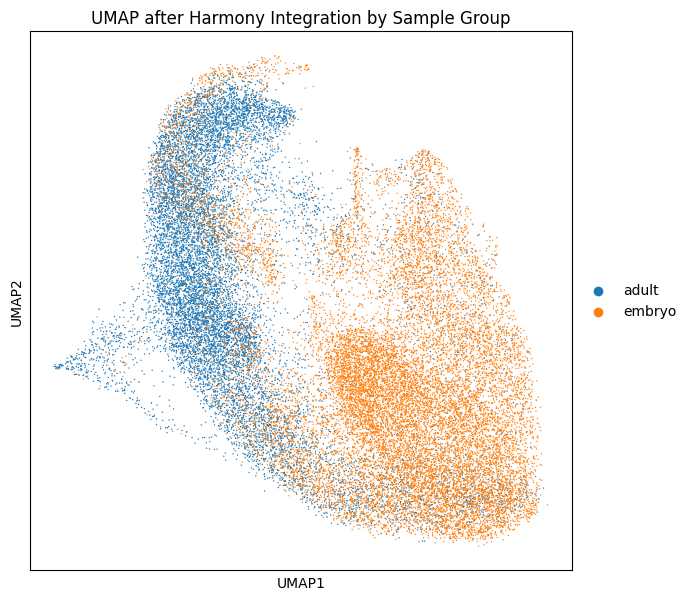

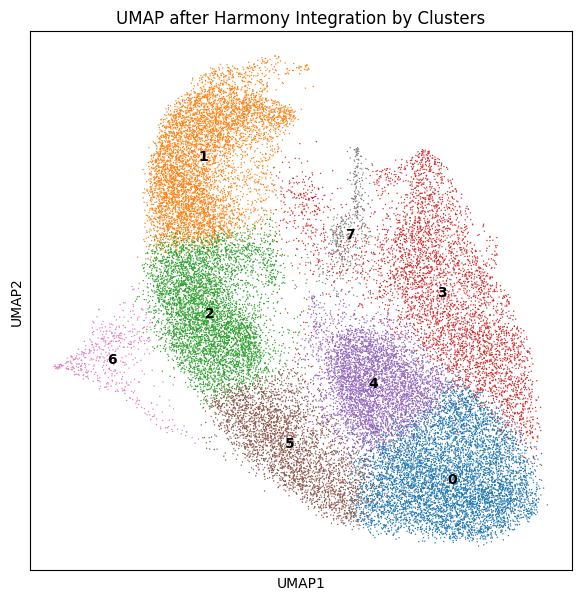

Unique clusters after Harmony integration: ['2', '1', '6', '5', '0', '4', '3', '7']
Categories (8, object): ['0', '1', '2', '3', '4', '5', '6', '7']


In [13]:
# Step 5: Plot UMAP after Harmony integration by sample_id
sc.pl.umap(
    adata, 
    color='population', 
    legend_loc='right margin', 
    title='UMAP after Harmony Integration by Sample Group',
)

# Step 6: Plot UMAP after Harmony integration by clusters
sc.pl.umap(
    adata, 
    color='leiden', 
    legend_loc='on data', 
    title='UMAP after Harmony Integration by Clusters',
)

# Step 7: Check the unique clusters after Harmony integration
print("Unique clusters after Harmony integration:", adata.obs['leiden'].unique())

In [14]:
# Ensure you are using the t_cell_clusters dataset after reclustering
# Check unique clusters to confirm
print("Unique clusters in rbc_clusters:", adata.obs['leiden'].unique())

# Step 1: Rank genes based on clustering results for T cell clusters
sc.tl.rank_genes_groups(adata, groupby='leiden', method='t-test')

# Step 2: Extract the marker genes table
marker_genes_table = pd.DataFrame(adata.uns["rank_genes_groups"]["names"]).T

# Step 3: Save the marker genes to a CSV file
marker_genes_table.to_csv("rbc-marker_genes_05.csv")

# Display the marker genes table
marker_genes_table

Unique clusters in rbc_clusters: ['2', '1', '6', '5', '0', '4', '3', '7']
Categories (8, object): ['0', '1', '2', '3', '4', '5', '6', '7']


,0,1,2,3,4,5,6,7,8,9,...,15580,15581,15582,15583,15584,15585,15586,15587,15588,15589
0,HBAD,HBA1,HBBA,TPT1,EIF3E,RPS20,HBE1,ITGB1BP3,CA2,TSPO2,...,ITM2B,HMGN1,EDF1,B2M,CNBP,ENSGALG00000004509,BF1,BF2,HINTW,CREG1
1,HINTW,BF2,HMGN1,B2M,BF1,TAL1,ITM2B,ENSGALG00000004509,HEXIM1,EDF1,...,ITGB1BP3,PMM1,RPS24,HBAD,NT5DC4,ADAL,GPI,RPS20,BPGM,CA2
2,B2M,BF2,BF1,IRF1,CREG1,IFI27L2,ENSGALG00000051188,AK2,TAPBP,EDF1,...,COX3,TPT1,ITGB1BP2,NT5DC2,TIMP3,NT5DC4,PMM1,GPI,ITGB1BP3,BPGM
3,COX3,COII,MT-CO1,ATP6,CYTB,ND5,ND6,ND1,ND4,MT-ND2,...,ENSGALG00000004509,ENSGALG00000029381,IFIT5,C15orf48,ENSGALG00000051188,IRF1,HINTW,BF1,B2M,BF2
4,CA2,BPGM,ITGB1BP3,RPS19,RPS24,RPS10,RPLP1,RPL37A,CA13,EEF2,...,IFIT5,TAPBP,IL15,ENSGALG00000029381,C15orf48,B2M,ENSGALG00000051188,IRF1,BF1,BF2
5,HBA1,HBBA,HBAD,GPX1,BG8,TMOD4,CA2,ENSGALG00000050131,ENSGALG00000040101,FOS,...,RFESD,MT-CO1,CNBP,ND6,CYTB,HPCAL1,ND5,COII,MAIP1,EIF1
6,IFI27L2,IFI6,OASL,B2M,IFIT5,BF2,CMPK2,IRF1,ENSGALG00000012072,BF1,...,NT5DC4,GPX3,ACTG1,ITGB1BP2,ENSGALG00000030776,GAPDH,HBE1,ENSGALG00000044661,PMM1,GPI
7,TMSB4X,MGP,GPX3,SPARC,EEF1A1,PPIA,RPS24,RPS20,ITGB1BP3,ENSGALG00000050132,...,NLRC5,IMPG2,ENSGALG00000051188,IRF1,BF2,IFI6,TPST2,ENSGALG00000053730,ENSGALG00000051088,ENSGALG00000052494


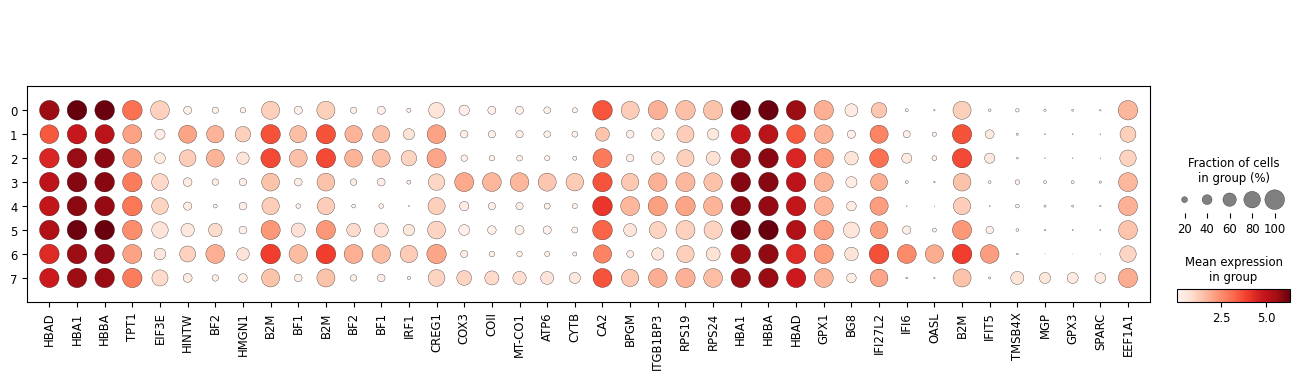

In [15]:
marker_genes_list = list(chain(*marker_genes_table.iloc[:, :5].values))
sc.pl.dotplot(
    adata,
    var_names=marker_genes_list,
    groupby="leiden",
)

In [16]:
adata.obs['leiden'].value_counts(),

(leiden
 0    6613
 1    5807
 2    5266
 3    4631
 4    4501
 5    3151
 6     485
 7     472
 Name: count, dtype: int64,)